# 22DM015 Final Project — Financial PhraseBank
## Person B: Parts 2 & 3 — BERT track (BERT, augmentation eval, full-data curve)

**Dataset:** `takala/financial_phrasebank`, config `sentences_allagree` (2,264 sentences).‍
**Labels:** 0 = negative, 1 = neutral, 2 = positive.‍

### Shared data contract (set by Person D — do NOT re-split)
- Splits are committed under `data/` as CSVs: `train` (1584), `val` (227), `test` (453), `labeled_32` (32).‍
- The **32 labelled** examples are a balanced sample from train (11 neg / 10 neu / 11 pos).‍
- Part 2 'unlabelled' data = train minus the 32 (`unlabeled_pool`).‍
- Evaluate headline numbers on **`test`** only; tune on **`val`**.‍ Use `eval_utils.evaluate` so we're comparable.‍
- Log every result with `eval_utils.log_result(...)` into `results/results.csv`.‍

> **AI disclosure:** any AI-generated code/text in this notebook must be watermarked and declared (course rule).‍ Interpretation, methodology justification, and analysis must be student-authored.‍

In [1]:
# watermark: AGLLM (AI-assisted content disclosure)
# --- Reproducibility seed (required by the assignment) ---
import os, random, sys
import numpy as np
SEED = 618
random.seed(SEED); np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Make the shared helpers importable (they live in the repo root, one level up).
sys.path.append(os.path.abspath('..'))
import data_utils as du
import eval_utils as eu

splits = du.load_splits()            # identical data for everyone
train, val, test = splits['train'], splits['val'], splits['test']
labeled_32 = splits['labeled_32']
pool = du.unlabeled_pool(splits)     # Part 2 'unlabelled' data
PERSON = 'B'
for k, v in splits.items():
    print(f'{k:11s} {len(v):5d}', dict(v['label_name'].value_counts()))

train        1584 {'neutral': np.int64(973), 'positive': np.int64(399), 'negative': np.int64(212)}
val           227 {'neutral': np.int64(140), 'positive': np.int64(57), 'negative': np.int64(30)}
test          453 {'neutral': np.int64(278), 'positive': np.int64(114), 'negative': np.int64(61)}
labeled_32     32 {'positive': np.int64(11), 'negative': np.int64(11), 'neutral': np.int64(10)}


> **Install (run once):** `transformers`, `torch`, `accelerate` are needed here.‍ On Python 3.14 torch wheels may be missing — use a 3.11/3.12 venv.‍

## Part 2a.‍ BERT with 32 labelled examples (0.5)
Fine-tune a BERT-family model on `labeled_32`, evaluate on `test`.‍ Expect instability with 32 examples — fix seed, report val + test.‍

In [2]:
# watermark: AGLLM (AI-assisted content disclosure)
# Part 2a: fine-tune a BERT classifier on the 32 labelled examples; evaluate on the shared
# test split. Also defines the helpers every later experiment cell reuses (one shared
# training protocol -> all rows in results.csv stay comparable).
import os, logging, warnings
# Tell transformers to skip its TensorFlow/Flax/Keras probe (we use PyTorch only).
# This prevents tf_keras from being imported, which is what emits the
# "tf.losses.sparse_softmax_cross_entropy is deprecated" notice. MUST be set BEFORE
# importing transformers.
os.environ.setdefault("USE_TF", "0")
os.environ.setdefault("USE_FLAX", "0")
os.environ.setdefault("TRANSFORMERS_NO_ADVISORY_WARNINGS", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")   # silence TF C++ logs if it still loads
logging.getLogger("tensorflow").setLevel(logging.ERROR)
# Silence the cosmetic "Redirects are currently not supported in Windows or MacOs" NOTE
# emitted by torch.distributed.elastic.multiprocessing.redirects when Trainer is imported
# on Windows/macOS. No-op on Linux. Set BEFORE importing transformers.
logging.getLogger("torch.distributed.elastic.multiprocessing.redirects").setLevel(logging.ERROR)
# Silence torchao's "Skipping import of cpp extensions due to incompatible torch version"
# message (https://github.com/pytorch/ao/issues/2919). We don't use torchao kernels here,
# so the Python fallbacks are fine. Covers both the logger and warnings.warn paths.
logging.getLogger("torchao").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message=r".*Skipping import of cpp extensions.*")

import pandas as pd, torch
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          Trainer, TrainingArguments, set_seed)

torch.set_num_threads(os.cpu_count() or 4)   # all trainings here are CPU-bound
MODEL = 'bert-base-uncased'      # general BERT; 'ProsusAI/finbert' reserved for the Part 3 SOA comparison
NUM_LABELS = 3
MAX_LEN = 128
AUG_CSV = '../data/augmented_32.csv'
GEN_CSV = '../data/llm_generated.csv'

tok = AutoTokenizer.from_pretrained(MODEL)


def encode(df, max_len=MAX_LEN):
    ds = Dataset.from_pandas(df[['text', 'label']], preserve_index=False)
    return ds.map(lambda b: tok(b['text'], truncation=True, padding='max_length', max_length=max_len),
                  batched=True)


def train_bert(train_df, out_dir, *, epochs=20, batch=8, max_len=MAX_LEN, log_epochs=False):
    """One shared fine-tuning protocol for every experiment in this notebook.
    Part 2 default: max_len 128 / batch 8 / 20 epochs. Part 3 curve: 64 / 16 / 3."""
    set_seed(SEED)                            # fresh, reproducible init per run
    model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=NUM_LABELS)
    args = TrainingArguments(
        output_dir=out_dir, seed=SEED,
        num_train_epochs=epochs, per_device_train_batch_size=batch,
        per_device_eval_batch_size=64, learning_rate=2e-5,
        eval_strategy='no', save_strategy='no',
        logging_strategy='epoch' if log_epochs else 'no',
        report_to='none', disable_tqdm=True,
    )
    trainer = Trainer(model=model, args=args, train_dataset=encode(train_df, max_len))
    trainer.train()
    trainer.eval_max_len = max_len            # so eval_split tokenizes like training did
    return trainer


def eval_split(trainer, df, max_len=None):
    """Predict on df and score it. Defaults to the max_len the trainer was trained with."""
    max_len = max_len or getattr(trainer, 'eval_max_len', MAX_LEN)
    pred = trainer.predict(encode(df, max_len)).predictions.argmax(-1)
    return eu.evaluate(df['label'].values, pred)


def logged(method, full_row=False):
    """Latest TEST row for (PERSON, MODEL, method) from the shared scoreboard.
    Delete a row from results.csv to force that experiment to re-run."""
    return eu.latest_result(PERSON, MODEL, method, full_row=full_row)


def notes_kv(notes):
    """Parse the 'k=v; k=v' segments of a notes string into a dict (prose segments
    ignored). Used to validate cached rows against the current inputs/protocol."""
    out = {}
    for seg in str(notes).split(';'):
        if '=' in seg:
            k, v = seg.split('=', 1)
            out[k.strip()] = v.strip()
    return out


fmt = eu.fmt


def delta_vs(m, ref_method):
    ref = logged(ref_method)
    if ref is not None:
        print(f"delta macro-F1 (vs {ref_method}): "
              f"{float(m['f1_macro']) - float(ref['f1_macro']):+.4f}")


# --- 2a: 32-shot fine-tune (RESUME-AWARE: reuses the logged row; ~6 min on CPU otherwise) ---
shot_m = logged('32-shot')
if shot_m is None:
    trainer = train_bert(labeled_32, '../.cache/bert_32shot', log_epochs=True)
    val_m = eval_split(trainer, val)
    shot_m = eval_split(trainer, test)
    # headline numbers logged on TEST; val macro-F1 kept in notes for the tuning record
    eu.log_result(MODEL, '32-shot', len(labeled_32), shot_m, person=PERSON,
                  notes=f"val_f1_macro={val_m['f1_macro']:.4f}")
    print('VAL :', fmt(val_m))
    print('[trained]')
else:
    print('[cached] (val macro-F1 is in the notes column of results.csv)')
print('2a 32-shot TEST:', fmt(shot_m))

[cached] (val macro-F1 is in the notes column of results.csv)
2a 32-shot TEST: {'accuracy': 0.6799, 'f1_macro': 0.6012, 'f1_weighted': 0.6977, 'f1_negative': 0.4651, 'f1_neutral': 0.8238, 'f1_positive': 0.5147}


### 2a — analysis

_TODO (student-authored)._ Comment on the 32-shot BERT result: macro-F1 vs the random/rule-based baselines and per-class F1 (where does it fail — minority classes?), the val/test gap, and the instability you expect from 32 examples.‍ Keep this interpretation in your own words (do not watermark; commit with `--no-verify`).‍


## Part 2b.‍ Train on Person D's augmented set (1)
Person D produces a non-LLM augmented training set (back-translation / EDA / etc.) under `data/augmented_32.csv`.‍ Re-train the SAME BERT on it and compare to 2a.‍

In [3]:
# watermark: AGLLM (AI-assisted content disclosure)
# Part 2b: re-train the SAME BERT (identical 2a protocol via train_bert) on Person D's
# back-translation augmented set; evaluate on test and compare to 2a.
# RESUME-AWARE: reuses the logged 'augmented' row (training is ~40 min on CPU).
# NOTE n_train_labeled=225 counts training ROWS; the real-label budget is still 32
# (the 225 rows are the 32 originals + paraphrases of them) — see the 2b analysis.
aug = pd.read_csv(AUG_CSV)
print('augmented set:', len(aug), 'rows ·', dict(aug['label_name'].value_counts()))

aug_m = logged('augmented')
if aug_m is None:
    aug_trainer = train_bert(aug, '../.cache/bert_2b')
    aug_val_m = eval_split(aug_trainer, val)
    aug_m = eval_split(aug_trainer, test)
    eu.log_result(MODEL, 'augmented', len(aug), aug_m, person=PERSON,
                  notes=f"back-translation aug from 32; n={len(aug)}; val_f1_macro={aug_val_m['f1_macro']:.4f}")
    print('[trained]')
else:
    print('[cached]')

print('2b augmented TEST:', fmt(aug_m))
delta_vs(aug_m, '32-shot')

augmented set: 225 rows · {'negative': np.int64(78), 'positive': np.int64(77), 'neutral': np.int64(70)}
[cached]
2b augmented TEST: {'accuracy': 0.7395, 'f1_macro': 0.6355, 'f1_weighted': 0.7474, 'f1_negative': 0.4671, 'f1_neutral': 0.8901, 'f1_positive': 0.5492}
delta macro-F1 (vs 32-shot): +0.0343


### 2b — analysis

_TODO (student-authored)._ Compare augmented vs 32-shot (2a): did back-translation help, and on which classes (per-class F1)?‍ Note that the 225 rows are not 225 new labels — they are paraphrases of the same 32, so discuss what augmentation can and cannot add (no new information, just regularisation / decision-boundary smoothing).‍ Mention back-translation's risk on financial negation.‍ Your words; commit with `--no-verify`.‍


## Part 2d.‍ Train on 32 + Person D's LLM-generated data (1)
Person D produces `data/llm_generated.csv`.‍ Train BERT on the 32 + generated points; analyse impact on metrics.‍

In [4]:
# watermark: AGLLM (AI-assisted content disclosure)
# Part 2d: train the SAME BERT (identical 2a protocol via train_bert) on the 32 real labels
# + Person D's LLM-generated points; evaluate on test.
# RESUME-AWARE + STALENESS-SAFE: a logged 'llm-generated' row is reused only while it
# matches the current llm_generated.csv (row count recorded in notes as n=...). If
# Person D revises the file, this cell retrains automatically instead of serving a row
# trained on the obsolete data. Skips cleanly while the file has not been committed yet.
prev = logged('llm-generated', full_row=True)
gen_m = None

if os.path.exists(GEN_CSV):
    gen = pd.read_csv(GEN_CSV)
    combo_2d = pd.concat([labeled_32[['text', 'label']], gen[['text', 'label']]], ignore_index=True)
    if prev is not None and notes_kv(prev['notes']).get('n') == str(len(combo_2d)):
        gen_m = {k: prev[k] for k in eu.METRIC_KEYS}
        print('[cached]')
    else:
        if prev is not None:
            print('[stale] llm_generated.csv changed since the logged row — retraining')
        print(f'training set: 32 real + {len(gen)} generated = {len(combo_2d)} rows ·',
              dict(combo_2d['label'].value_counts().sort_index()))
        gen_trainer = train_bert(combo_2d, '../.cache/bert_2d')
        gen_val_m = eval_split(gen_trainer, val)
        gen_m = eval_split(gen_trainer, test)
        eu.log_result(MODEL, 'llm-generated', len(combo_2d), gen_m, person=PERSON,
                      notes=f"n={len(combo_2d)}; gen={len(gen)}; val_f1_macro={gen_val_m['f1_macro']:.4f}")
        print('[trained]')
elif prev is not None:                # row exists but the file is gone — keep the row
    gen_m = {k: prev[k] for k in eu.METRIC_KEYS}
    print('[cached] (llm_generated.csv not present to validate against)')
else:
    print('[waiting] ../data/llm_generated.csv not committed yet (Person D).')

if gen_m is not None:
    print('2d 32+LLM-gen TEST:', fmt(gen_m))
    delta_vs(gen_m, '32-shot')
    delta_vs(gen_m, 'augmented')

[cached]
2d 32+LLM-gen TEST: {'accuracy': 0.8653, 'f1_macro': 0.8406, 'f1_weighted': 0.8622, 'f1_negative': 0.8741, 'f1_neutral': 0.911, 'f1_positive': 0.7368}
delta macro-F1 (vs 32-shot): +0.2395
delta macro-F1 (vs augmented): +0.2052


## Part 2e.‍ Optimal technique (0.5)
Apply the best technique(s) from 2a/2b/2d.‍ Comment + propose improvements (student-authored).‍

In [5]:
# watermark: AGLLM (AI-assisted content disclosure)
# Part 2e: apply the most effective technique(s) from 2a/2b/2d — combine ALL training
# sources (32 real + augmented + LLM-generated), dedup on text, train with the SAME 2a
# protocol so the row stays comparable.
# Requires the 2d data: augmented_32.csv already CONTAINS the 32 originals, so a
# "32 + augmented" combo would dedup back to exactly the 2b training set — training it
# again would waste ~45 CPU-minutes to reproduce the 2b row.
# RESUME-AWARE + STALENESS-SAFE: the logged 'optimal-combo' row is reused only if both
# the recipe AND the deduped row count (recorded as k=v in notes) match the current
# input files; if either source CSV changes, it retrains automatically.
part2 = {m: logged(m) for m in ['32-shot', 'augmented', 'llm-generated']}
part2 = {m: v for m, v in part2.items() if v is not None}
if part2:
    board = (pd.DataFrame(part2).T[['accuracy', 'f1_macro']].astype(float)
             .sort_values('f1_macro', ascending=False))
    print('Part 2 scoreboard (test):')
    print(board.round(4), '\n')

if not os.path.exists(GEN_CSV):
    print('[waiting] 2e needs ../data/llm_generated.csv (see note above) — re-run once 2d data lands.')
else:
    recipe = '32-real+augmented+llm-generated'
    combo_2e = (pd.concat([labeled_32[['text', 'label']],
                           pd.read_csv(AUG_CSV)[['text', 'label']],
                           pd.read_csv(GEN_CSV)[['text', 'label']]], ignore_index=True)
                .drop_duplicates(subset='text', ignore_index=True))
    prev = logged('optimal-combo', full_row=True)
    kv = notes_kv(prev['notes']) if prev is not None else {}
    if kv.get('recipe') == recipe and kv.get('n') == str(len(combo_2e)):
        best_m = {k: prev[k] for k in eu.METRIC_KEYS}
        print(f'[cached] optimal-combo ({recipe}, n={len(combo_2e)})')
    else:
        if prev is not None:
            print('[stale] input files changed since the logged row — retraining')
        print(f'optimal combo = {recipe} -> {len(combo_2e)} unique rows ·',
              dict(combo_2e['label'].value_counts().sort_index()))
        best_trainer = train_bert(combo_2e, '../.cache/bert_2e')
        best_val_m = eval_split(best_trainer, val)
        best_m = eval_split(best_trainer, test)
        eu.log_result(MODEL, 'optimal-combo', len(combo_2e), best_m, person=PERSON,
                      notes=f"recipe={recipe}; n={len(combo_2e)}; val_f1_macro={best_val_m['f1_macro']:.4f}")
        print('[trained]')
    print('2e optimal-combo TEST:', fmt(best_m))
    if part2:
        top = board['f1_macro'].idxmax()
        print(f"delta macro-F1 (optimal-combo - best single = {top}): "
              f"{float(best_m['f1_macro']) - float(board.loc[top, 'f1_macro']):+.4f}")

Part 2 scoreboard (test):
               accuracy  f1_macro
llm-generated    0.8653    0.8406
augmented        0.7395    0.6355
32-shot          0.6799    0.6012 



optimal combo = 32-real+augmented+llm-generated -> 585 unique rows · {0: np.int64(198), 1: np.int64(190), 2: np.int64(197)}


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/585 [00:00<?, ? examples/s]

C:\EC\python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

Map:   0%|          | 0/227 [00:00<?, ? examples/s]

C:\EC\python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Map:   0%|          | 0/453 [00:00<?, ? examples/s]

C:\EC\python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[trained]
2e optimal-combo TEST: {'accuracy': 0.8477, 'f1_macro': 0.7997, 'f1_weighted': 0.8453, 'f1_negative': 0.7742, 'f1_neutral': 0.9173, 'f1_positive': 0.7077}
delta macro-F1 (optimal-combo - best single = llm-generated): -0.0409


### 2e — comments & proposed improvements

_TODO (student-authored)._ State which Part 2 technique won on test macro-F1 and whether combining the training sources beat the best single one.‍ Propose improvements: better generation prompts (hard/ambiguous cases, minority classes), label-preserving augmentation checks, semi-supervised use of the unlabelled pool (self-training / pseudo-labels), val-based early stopping.‍ Your words; commit with `--no-verify`.‍

## Part 3.‍ Full-dataset SOA comparison (2)
3a.‍ Train on 1/10/25/50/75/100% of `train` (use `du.subset_by_fraction`).‍ 3b.‍ Plot the learning curve.‍ 3c.‍ Fold in Part 2 techniques.‍ 3d.‍ Methodology analysis.‍

In [6]:
# watermark: AGLLM (AI-assisted content disclosure)
# Part 3a: data-scaling curve — fine-tune a fresh BERT on increasing fractions of train,
# evaluate on test. Reuses train_bert/eval_split from 2a with a lighter fixed protocol
# (max_len 64, batch 16, 3 epochs) so the curve isolates data quantity.
# RESUME-AWARE + PROTOCOL-SAFE: a logged fraction is reused only if its notes match the
# current CURVE protocol (epochs/maxlen) — editing CURVE retrains instead of silently
# mixing protocols. Six bert-base trainings take ~1.5 h on CPU; delete rows to force.
# NOTE: du.subset_by_fraction samples each fraction independently (stratified, same
# seed) — fractions are NOT nested subsets of each other; see its docstring.
CURVE = dict(epochs=3, batch=16, max_len=64)
FRACTIONS = [0.01, 0.10, 0.25, 0.50, 0.75, 1.00]

curve_rows = []
for f in FRACTIONS:
    method = f'full-{int(f * 100)}%'
    sub = du.subset_by_fraction(train, f)
    prev = logged(method, full_row=True)
    m = None
    if prev is not None:
        kv = notes_kv(prev['notes'])
        if kv.get('epochs') == str(CURVE['epochs']) and kv.get('maxlen') == str(CURVE['max_len']):
            m = {k: prev[k] for k in eu.METRIC_KEYS}
            print(f"frac={f:>4}  n={len(sub):4d}  [cached]  macroF1={float(m['f1_macro']):.4f}")
        else:
            print(f"frac={f:>4}  [stale] logged row used a different protocol — retraining")
    if m is None:
        tr = train_bert(sub, '../.cache/bert_curve', **CURVE)
        m = eval_split(tr, test)
        eu.log_result(MODEL, method, len(sub), m, person=PERSON,
                      notes=f"frac={f}; epochs={CURVE['epochs']}; maxlen={CURVE['max_len']}")
        print(f"frac={f:>4}  n={len(sub):4d}  [trained] macroF1={float(m['f1_macro']):.4f}")
    curve_rows.append({'frac': f, 'n_train': len(sub), **m})

pd.DataFrame(curve_rows)

frac=0.01  n=  15  [cached]  macroF1=0.2839


frac= 0.1  n= 158  [cached]  macroF1=0.5054
frac=0.25  n= 396  [cached]  macroF1=0.5330
frac= 0.5  n= 792  [cached]  macroF1=0.9369
frac=0.75  n=1188  [cached]  macroF1=0.9462
frac= 1.0  n=1584  [cached]  macroF1=0.9587


,frac,n_train,accuracy,f1_macro,f1_weighted,f1_negative,f1_neutral,f1_positive
0,0.01,15,0.379691,0.283901,0.369218,0.027027,0.436548,0.388128
1,0.10,158,0.763797,0.505413,0.713277,0.000000,0.916239,0.600000
2,0.25,396,0.792494,0.533047,0.743541,0.000000,0.942207,0.656934
3,0.50,792,0.951435,0.936930,0.951398,0.930233,0.974729,0.905830
4,0.75,1188,0.962472,0.946171,0.962443,0.929134,0.985612,0.923767
5,1.00,1584,0.973510,0.958730,0.973657,0.936508,0.992780,0.946903


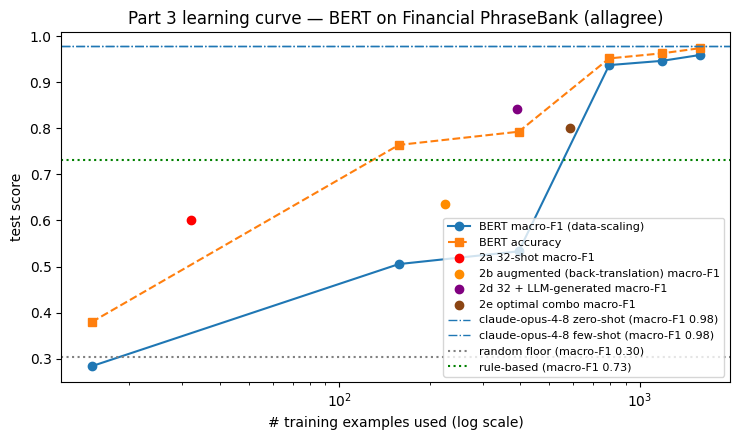

,method,n_train_labeled,accuracy,f1_macro,f1_weighted
0,full-1%,15,0.379691,0.283901,0.369218
1,full-10%,158,0.763797,0.505413,0.713277
2,full-25%,396,0.792494,0.533047,0.743541
3,full-50%,792,0.951435,0.936930,0.951398
4,full-75%,1188,0.962472,0.946171,0.962443
5,full-100%,1584,0.973510,0.958730,0.973657
6,32-shot,32,0.679912,0.601195,0.697692
7,augmented,225,0.739514,0.635466,0.747358
8,llm-generated,392,0.865342,0.840649,0.862219
9,optimal-combo,585,0.847682,0.799717,0.845260


In [7]:
# watermark: AGLLM (AI-assisted content disclosure)
# Part 3b: learning curve from the shared results scoreboard.
# Part 3c: overlay every Part 2 technique logged in results.csv on the same axes, each at
# the number of training rows it used — i.e. "how many real labels is each technique worth?"
# Person C's LLM rows (zero-/few-shot) and Person A's Part 1 baselines are drawn as
# horizontal reference lines (no x-position on the log axis). Baselines fall back to the
# Part 1 notebook's numbers until Person A logs them through eu.log_result.
import matplotlib.pyplot as plt

res = pd.read_csv(eu.RESULTS_CSV)
bsel = (res['person'] == PERSON) & (res['model'] == MODEL)
# log_result upserts on (person, model, method, split), so rows are already unique
curve = res[bsel & res['method'].str.startswith('full-')].sort_values('n_train_labeled')

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(curve['n_train_labeled'], curve['f1_macro'], marker='o', label='BERT macro-F1 (data-scaling)')
ax.plot(curve['n_train_labeled'], curve['accuracy'], marker='s', ls='--', label='BERT accuracy')

# Part 2 techniques (3c) — only the ones already logged are drawn, so this cell
# degrades gracefully until 2d/2e have run
TECHNIQUES = [('32-shot', 'red', '2a 32-shot'),
              ('augmented', 'darkorange', '2b augmented (back-translation)'),
              ('llm-generated', 'purple', '2d 32 + LLM-generated'),
              ('optimal-combo', 'saddlebrown', '2e optimal combo')]
tech_rows = []
for method, color, label in TECHNIQUES:
    row = res[bsel & (res['method'] == method)]
    if len(row):
        ax.scatter(row['n_train_labeled'], row['f1_macro'], color=color, zorder=5,
                   label=f'{label} macro-F1')
        tech_rows.append(row)

# Person C's zero-/few-shot LLM rows (Part 2c) as horizontal reference lines
llm = res[(res['person'] == 'C') & res['method'].isin(['zero-shot', 'few-shot'])]
for _, r in llm.iterrows():
    ax.axhline(float(r['f1_macro']), ls='-.', lw=1,
               label=f"{r['model']} {r['method']} (macro-F1 {float(r['f1_macro']):.2f})")

# Part 1 reference floors (test split): read Person A's logged rows when available,
# otherwise fall back to the numbers from the Part 1 notebook
for pattern, fallback, color, label in [('random', 0.3035, 'gray', 'random floor'),
                                        ('rule', 0.7304, 'green', 'rule-based')]:
    row = res[res['method'].str.contains(pattern, case=False, na=False)]
    f1 = float(row['f1_macro'].iloc[-1]) if len(row) else fallback
    ax.axhline(f1, color=color, ls=':', label=f'{label} (macro-F1 {f1:.2f})')

ax.set_xscale('log')
ax.set_xlabel('# training examples used (log scale)')
ax.set_ylabel('test score')
ax.set_title('Part 3 learning curve — BERT on Financial PhraseBank (allagree)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

cols = ['method', 'n_train_labeled', 'accuracy', 'f1_macro', 'f1_weighted']
pd.concat([curve[cols]] + [r[cols] for r in tech_rows] + ([llm[cols]] if len(llm) else []),
          ignore_index=True)

### 3c — technique comparison &nbsp;·&nbsp; 3d — methodology analysis

**3c (fold in Part 2 techniques):** the cell above overlays every Part 2 row logged in `results/results.csv` (`32-shot`, `augmented`, `llm-generated`, `optimal-combo`) on the data-scaling curve, each plotted at the number of training rows it used — i.e.‍ "how many real labels is each technique worth?".‍ Points appear automatically as 2d/2e get logged; re-run the cell after they finish.‍

_TODO (student-authored) — 3d methodology analysis._ Compare all methods (random / rule-based / 32-shot / augmentation / LLM-generated / full-data curve): where each helps, the data-efficiency story, limitations, and what you'd do with more compute.‍ Your words; commit with `--no-verify`.‍
